In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
bankdata = pd.read_csv("/content/drive/MyDrive/bill.csv")

In [ ]:
bankdata.shape

(1200, 5)

In [ ]:
bankdata.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
bankdata.isnull().sum()

,0
variance,0
skewness,0
curtosis,0
entropy,0
class,0


In [ ]:
print(bankdata['class'].value_counts())

class
1    612
0    588
Name: count, dtype: int64


In [ ]:
# Split the data into attributes/features and labels/target
X = bankdata.drop('class', axis=1)
y = bankdata['class']
y

,class
0,0
1,0
2,0
3,0
4,0
...,...
1195,0
1196,0
1197,1
1198,1


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)
X_train

,variance,skewness,curtosis,entropy
121,4.639719,-3.110685,3.326091,-1.825086
1118,3.646743,11.219206,-4.230033,-4.944675
208,5.639220,10.741076,-6.195826,-4.227217
344,0.658762,-4.353425,4.918483,-0.500894
144,3.150687,8.870358,-1.705165,-0.369235
...,...,...,...,...
972,3.244215,-2.846987,7.784654,-0.051688
308,3.427688,-0.182858,-0.202604,-1.640369
516,2.663016,-3.436127,7.083746,-1.827124
634,1.317014,-1.879199,4.156693,3.122545


In [ ]:
from sklearn.svm import SVC
svclassifier = SVC(kernel='linear')
svclassifier.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
#To make predictions
y_pred = svclassifier.predict(X_test)

Evaluating the Algorithm

Confusion matrix, precision, recall, and F1 measures are the most commonly used metrics for classification tasks. Scikit-Learn's metrics library contains the classification_report and confusion_matrix methods, which can be readily used to find out the values for these important metrics.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[ 32  82]
 [ 25 101]]
              precision    recall  f1-score   support

           0       0.56      0.28      0.37       114
           1       0.55      0.80      0.65       126

    accuracy                           0.55       240
   macro avg       0.56      0.54      0.51       240
weighted avg       0.56      0.55      0.52       240



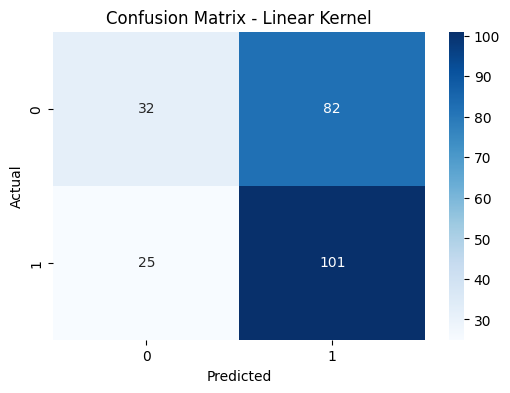

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix for Linear Kernel
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, svclassifier.predict(X_test)), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Linear Kernel')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

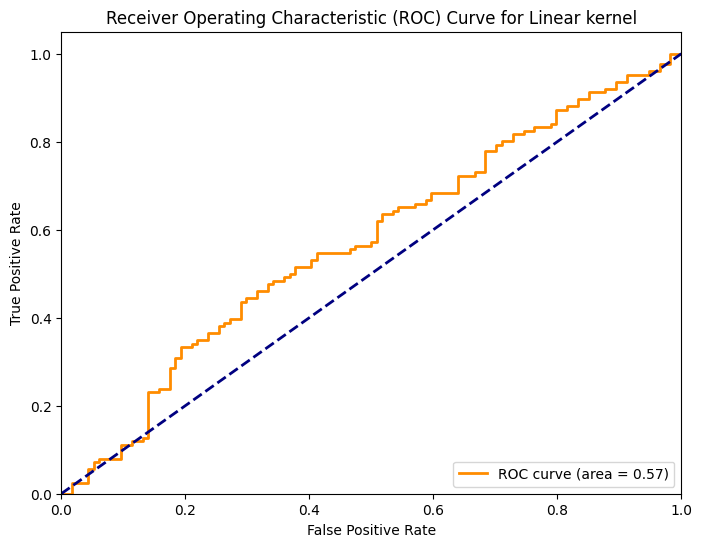

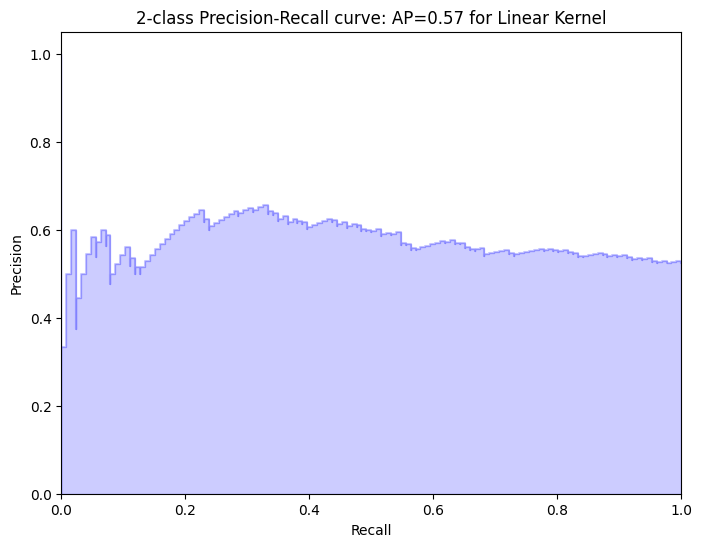

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, svclassifier.decision_function(X_test))
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Linear kernel')
plt.legend(loc="lower right")
plt.show()

# Calculate Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, svclassifier.decision_function(X_test))
average_precision = average_precision_score(y_test, svclassifier.decision_function(X_test))

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', alpha=0.2, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('2-class Precision-Recall curve: AP={0:0.2f} for Linear Kernel'.format(average_precision))
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
svclassifier = SVC(kernel='linear')
svclassifier.fit(X_train, y_train)

y_pred = svclassifier.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[ 32  82]
 [ 25 101]]
              precision    recall  f1-score   support

           0       0.56      0.28      0.37       114
           1       0.55      0.80      0.65       126

    accuracy                           0.55       240
   macro avg       0.56      0.54      0.51       240
weighted avg       0.56      0.55      0.52       240



2. Polynomial

In [ ]:
from sklearn.svm import SVC
svclassifier = SVC(kernel='poly')
svclassifier.fit(X_train, y_train)

SVC(kernel='poly')

In [ ]:
#To make predictions
y_pred = svclassifier.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[34 80]
 [40 86]]
              precision    recall  f1-score   support

           0       0.46      0.30      0.36       114
           1       0.52      0.68      0.59       126

    accuracy                           0.50       240
   macro avg       0.49      0.49      0.48       240
weighted avg       0.49      0.50      0.48       240



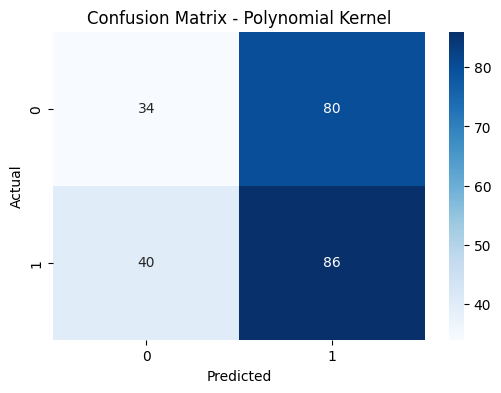

In [ ]:
# Confusion matrix for Polynomial Kernel
svclassifier_poly = SVC(kernel='poly')
svclassifier_poly.fit(X_train, y_train)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, svclassifier_poly.predict(X_test)), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Polynomial Kernel')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

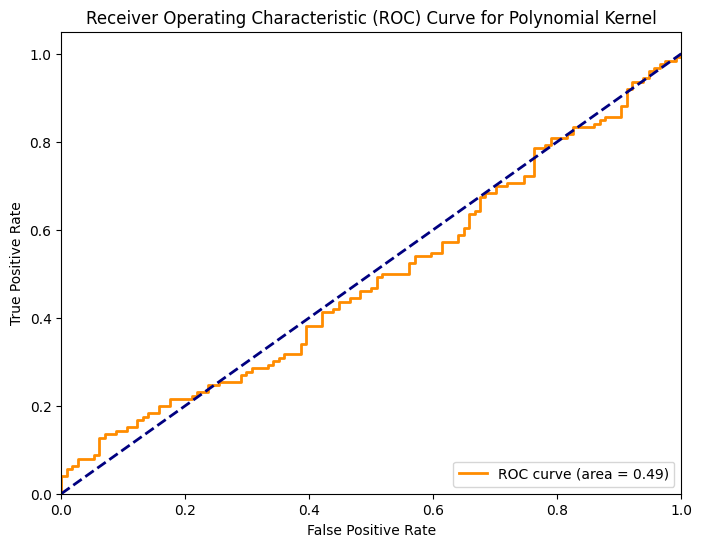

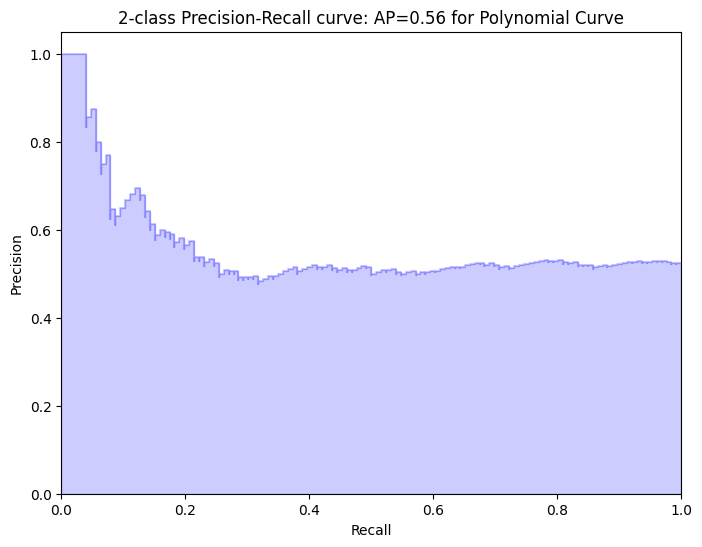

In [ ]:
# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, svclassifier.decision_function(X_test))
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Polynomial Kernel')
plt.legend(loc="lower right")
plt.show()

# Calculate Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, svclassifier.decision_function(X_test))
average_precision = average_precision_score(y_test, svclassifier.decision_function(X_test))

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', alpha=0.2, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('2-class Precision-Recall curve: AP={0:0.2f} for Polynomial Curve'.format(average_precision))
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
svclassifier = SVC(kernel='poly')
svclassifier.fit(X_train, y_train)

y_pred = svclassifier.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[34 80]
 [40 86]]
              precision    recall  f1-score   support

           0       0.46      0.30      0.36       114
           1       0.52      0.68      0.59       126

    accuracy                           0.50       240
   macro avg       0.49      0.49      0.48       240
weighted avg       0.49      0.50      0.48       240



3. RBF

In [ ]:
from sklearn.svm import SVC
svclassifier = SVC(kernel='rbf')
svclassifier.fit(X_train, y_train)

SVC()

In [ ]:
#To make predictions
y_pred = svclassifier.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[51 63]
 [54 72]]
              precision    recall  f1-score   support

           0       0.49      0.45      0.47       114
           1       0.53      0.57      0.55       126

    accuracy                           0.51       240
   macro avg       0.51      0.51      0.51       240
weighted avg       0.51      0.51      0.51       240



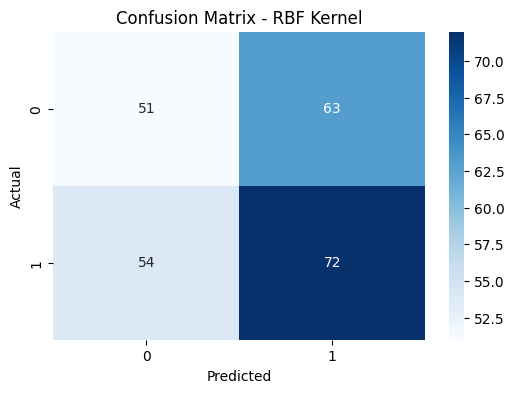

In [ ]:
# Confusion matrix for RBF Kernel
svclassifier_rbf = SVC(kernel='rbf')
svclassifier_rbf.fit(X_train, y_train)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, svclassifier_rbf.predict(X_test)), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - RBF Kernel')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

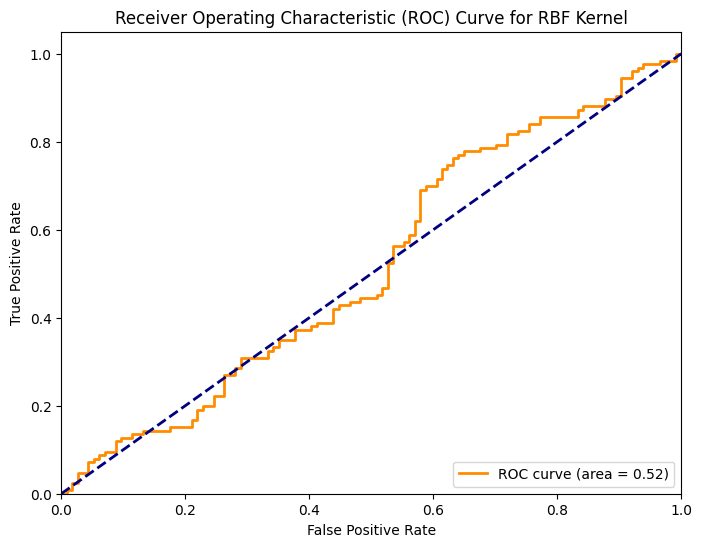

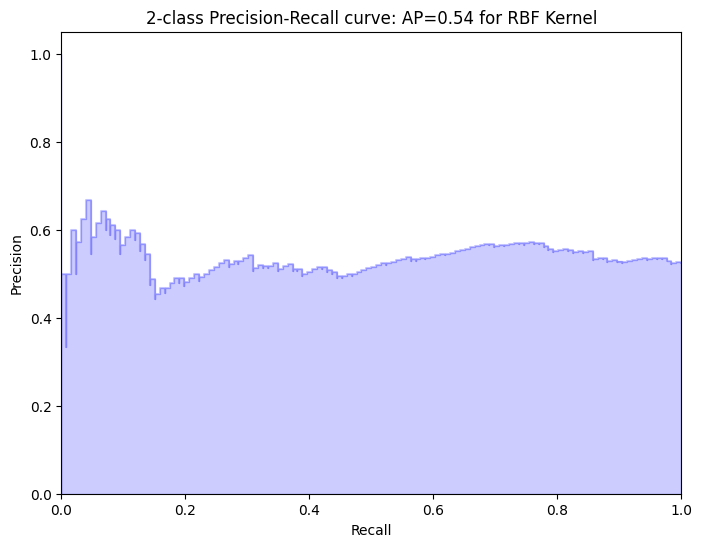

In [ ]:
# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, svclassifier.decision_function(X_test))
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for RBF Kernel')
plt.legend(loc="lower right")
plt.show()

# Calculate Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, svclassifier.decision_function(X_test))
average_precision = average_precision_score(y_test, svclassifier.decision_function(X_test))

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', alpha=0.2, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('2-class Precision-Recall curve: AP={0:0.2f} for RBF Kernel'.format(average_precision))
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
svclassifier = SVC(kernel='rbf')
svclassifier.fit(X_train, y_train)

y_pred = svclassifier.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[51 63]
 [54 72]]
              precision    recall  f1-score   support

           0       0.49      0.45      0.47       114
           1       0.53      0.57      0.55       126

    accuracy                           0.51       240
   macro avg       0.51      0.51      0.51       240
weighted avg       0.51      0.51      0.51       240



Hyperparameter tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1, 1, 10, 100],
              'gamma': ['scale', 0.1, 0.01, 0.001],
              'kernel': ['rbf', 'poly', 'sigmoid']}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.1s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.1s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.1s
[CV] END .................C=0.1, gamma=scale, kernel=sigmoid; total time=   0.3s
[CV] END .................C=0.1, gamma=scale, k

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'poly', 'sigmoid']},
             verbose=2)

In [ ]:
svclassifier = SVC(kernel='poly', C=10, gamma='scale')
svclassifier.fit(X_train, y_train)

y_pred = svclassifier.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[61 53]
 [65 61]]
              precision    recall  f1-score   support

           0       0.48      0.54      0.51       114
           1       0.54      0.48      0.51       126

    accuracy                           0.51       240
   macro avg       0.51      0.51      0.51       240
weighted avg       0.51      0.51      0.51       240



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'gamma': [1e-4, 1e-3, 1e-2, 0.1, 1, 10],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END ...................C=0.01, gamma=0.0001, kernel=rbf; total time=   0.0s
[CV] END ...................C=0.01, gamma=0.0001, kernel=rbf; total time=   0.1s
[CV] END ...................C=0.01, gamma=0.0001, kernel=rbf; total time=   0.0s
[CV] END ...................C=0.01, gamma=0.0001, kernel=rbf; total time=   0.0s
[CV] END ...................C=0.01, gamma=0.0001, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.01, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.01, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.01, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.01, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.01, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.01, gamma=0.0

Iris Dataset

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

# Assign colum names to the dataset
colnames = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']

# Read dataset to pandas dataframe
irisdata = pd.read_csv(url, names=colnames)

In [ ]:
irisdata


,sepal-length,sepal-width,petal-length,petal-width,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
irisdata.isnull().sum()

,0
sepal-length,0
sepal-width,0
petal-length,0
petal-width,0
Class,0


In [ ]:
print(irisdata['Class'].value_counts())

Class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [ ]:
X = irisdata.drop('Class', axis=1)
y = irisdata['Class']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [ ]:
from sklearn.svm import SVC
svclassifier = SVC(kernel='poly', degree=8)
#svclassifier = SVC(kernel='rbf') #Gaussian Kernel
svclassifier.fit(X_train, y_train)

SVC(degree=8, kernel='poly')

In [ ]:
y_pred = svclassifier.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 9  0  0]
 [ 0 10  1]
 [ 0  1  9]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         9
Iris-versicolor       0.91      0.91      0.91        11
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.94      0.94      0.94        30
   weighted avg       0.93      0.93      0.93        30



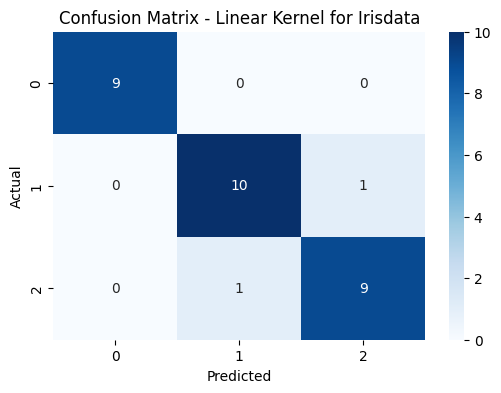

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix for Linear Kernel
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, svclassifier.predict(X_test)), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Linear Kernel for Irisdata')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'gamma': [1e-4, 1e-3, 1e-2, 0.1, 1, 10],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END ...................C=0.01, gamma=0.0001, kernel=rbf; total time=   0.0s
[CV] END ...................C=0.01, gamma=0.0001, kernel=rbf; total time=   0.0s
[CV] END ...................C=0.01, gamma=0.0001, kernel=rbf; total time=   0.0s
[CV] END ...................C=0.01, gamma=0.0001, kernel=rbf; total time=   0.0s
[CV] END ...................C=0.01, gamma=0.0001, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.01, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.01, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.01, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.01, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.01, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.01, gamma=0.0

In [ ]:
svclassifier = SVC(kernel='rbf', C=100, gamma=0.01)
svclassifier.fit(X_train, y_train)

y_pred = svclassifier.predict(X_test)


from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


[[ 9  0  0]
 [ 0 10  1]
 [ 0  0 10]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         9
Iris-versicolor       1.00      0.91      0.95        11
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1, 1, 10, 100],
              'gamma': ['scale', 0.1, 0.01, 0.001],
              'kernel': ['rbf', 'poly', 'sigmoid']}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END .................C=0.1, gamma=scale, kernel=sigmoid; total time=   0.0s
[CV] END .................C=0.1, gamma=scale, k

In [ ]:

svclassifier = SVC(kernel='poly', C=10, gamma='scale')
svclassifier.fit(X_train, y_train)

y_pred = svclassifier.predict(X_test)


from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


[[ 9  0  0]
 [ 0 10  1]
 [ 0  1  9]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         9
Iris-versicolor       0.91      0.91      0.91        11
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.94      0.94      0.94        30
   weighted avg       0.93      0.93      0.93        30

